# Sensitivity Analysis

In this notebook, we test how Monte Carlo simulation results change when key assumptions are modified.

The analysis focuses on:

- number of simulations
- investment time horizon
- initial portfolio value
- risk-free rate assumptions

The objective is to evaluate the robustness of Monte Carlo risk estimates such as Value at Risk, Expected Shortfall, and Probability of Loss.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [2]:
# Base portfolio: Balanced allocation
weights = pd.Series({
    "SPY": 0.40,
    "QQQ": 0.30,
    "TLT": 0.20,
    "GLD": 0.10
})

weights = weights[returns.columns]

initial_portfolio_value = 10_000
base_n_simulations = 10_000
base_time_horizon = 252
trading_days = 252

weights

GLD    0.1
QQQ    0.3
SPY    0.4
TLT    0.2
dtype: float64

In [3]:
def run_parametric_monte_carlo(
    returns,
    weights,
    initial_value=10_000,
    n_simulations=10_000,
    time_horizon=252,
    random_seed=42
):
    """
    Runs a parametric Monte Carlo simulation using historical mean returns
    and covariance matrix.
    """
    np.random.seed(random_seed)

    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    simulated_asset_returns = np.random.multivariate_normal(
        mean=mean_returns,
        cov=cov_matrix,
        size=(n_simulations, time_horizon)
    )

    simulated_portfolio_returns = simulated_asset_returns @ weights.values

    portfolio_values = initial_value * np.cumprod(
        1 + simulated_portfolio_returns,
        axis=1
    )

    final_values = portfolio_values[:, -1]

    return portfolio_values, final_values


def calculate_risk_metrics(final_values, initial_value=10_000):
    """
    Calculates simulation-based risk metrics.
    """
    simulated_returns = final_values / initial_value - 1

    var_95 = np.percentile(simulated_returns, 5)
    expected_shortfall_95 = simulated_returns[
        simulated_returns <= var_95
    ].mean()

    return {
        "Mean Final Value": final_values.mean(),
        "Median Final Value": np.median(final_values),
        "Probability of Loss": np.mean(final_values < initial_value),
        "95% Value at Risk": var_95,
        "95% Expected Shortfall": expected_shortfall_95
    }

## Sensitivity to Number of Simulations

We test whether Monte Carlo risk estimates become more stable as the number of simulations increases.

In [4]:
simulation_counts = [1_000, 5_000, 10_000, 25_000]

simulation_sensitivity_results = []

for n_sims in simulation_counts:
    paths, final_values = run_parametric_monte_carlo(
        returns=returns,
        weights=weights,
        initial_value=initial_portfolio_value,
        n_simulations=n_sims,
        time_horizon=base_time_horizon,
        random_seed=42
    )

    metrics = calculate_risk_metrics(
        final_values,
        initial_value=initial_portfolio_value
    )

    metrics["Number of Simulations"] = n_sims
    simulation_sensitivity_results.append(metrics)

simulation_sensitivity_df = pd.DataFrame(simulation_sensitivity_results)

simulation_sensitivity_df = simulation_sensitivity_df[
    [
        "Number of Simulations",
        "Mean Final Value",
        "Median Final Value",
        "Probability of Loss",
        "95% Value at Risk",
        "95% Expected Shortfall"
    ]
]

simulation_sensitivity_df.to_csv(
    OUTPUTS_DIR / "sensitivity_number_of_simulations.csv",
    index=False
)

simulation_sensitivity_df

,Number of Simulations,Mean Final Value,Median Final Value,Probability of Loss,95% Value at Risk,95% Expected Shortfall
0,1000,11536.287665,11336.321508,0.20000,-0.111616,-0.169223
1,5000,11513.452667,11385.541002,0.19320,-0.113400,-0.167234
2,10000,11500.850986,11382.972590,0.19300,-0.111579,-0.164366
3,25000,11490.423471,11367.284611,0.19664,-0.111700,-0.164806


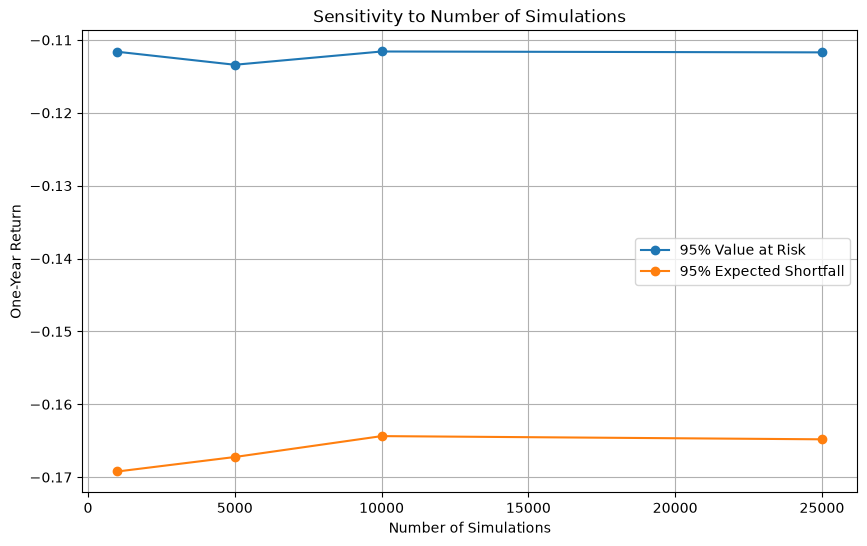

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    simulation_sensitivity_df["Number of Simulations"],
    simulation_sensitivity_df["95% Value at Risk"],
    marker="o",
    label="95% Value at Risk"
)

plt.plot(
    simulation_sensitivity_df["Number of Simulations"],
    simulation_sensitivity_df["95% Expected Shortfall"],
    marker="o",
    label="95% Expected Shortfall"
)

plt.title("Sensitivity to Number of Simulations")
plt.xlabel("Number of Simulations")
plt.ylabel("One-Year Return")
plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "sensitivity_number_of_simulations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sensitivity to Time Horizon

We test how downside risk changes when the investment horizon increases from short-term to long-term periods.

In [7]:
time_horizons = {
    "3 Months": 63,
    "6 Months": 126,
    "1 Year": 252,
    "3 Years": 756,
    "5 Years": 1260
}

horizon_sensitivity_results = []

for horizon_name, horizon_days in time_horizons.items():
    paths, final_values = run_parametric_monte_carlo(
        returns=returns,
        weights=weights,
        initial_value=initial_portfolio_value,
        n_simulations=base_n_simulations,
        time_horizon=horizon_days,
        random_seed=42
    )

    metrics = calculate_risk_metrics(
        final_values,
        initial_value=initial_portfolio_value
    )

    metrics["Time Horizon"] = horizon_name
    metrics["Trading Days"] = horizon_days
    horizon_sensitivity_results.append(metrics)

horizon_sensitivity_df = pd.DataFrame(horizon_sensitivity_results)

horizon_sensitivity_df = horizon_sensitivity_df[
    [
        "Time Horizon",
        "Trading Days",
        "Mean Final Value",
        "Median Final Value",
        "Probability of Loss",
        "95% Value at Risk",
        "95% Expected Shortfall"
    ]
]

horizon_sensitivity_df.to_csv(
    OUTPUTS_DIR / "sensitivity_time_horizon.csv",
    index=False
)

horizon_sensitivity_df

,Time Horizon,Trading Days,Mean Final Value,Median Final Value,Probability of Loss,95% Value at Risk,95% Expected Shortfall
0,3 Months,63,10354.178081,10329.579248,0.3339,-0.086357,-0.115645
1,6 Months,126,10729.094429,10678.920572,0.2685,-0.101285,-0.141805
2,1 Year,252,11500.850986,11382.972590,0.1930,-0.111579,-0.164366
3,3 Years,756,15176.948130,14672.935455,0.0719,-0.047037,-0.140688
4,5 Years,1260,20014.128265,18954.758754,0.0281,0.085173,-0.046291


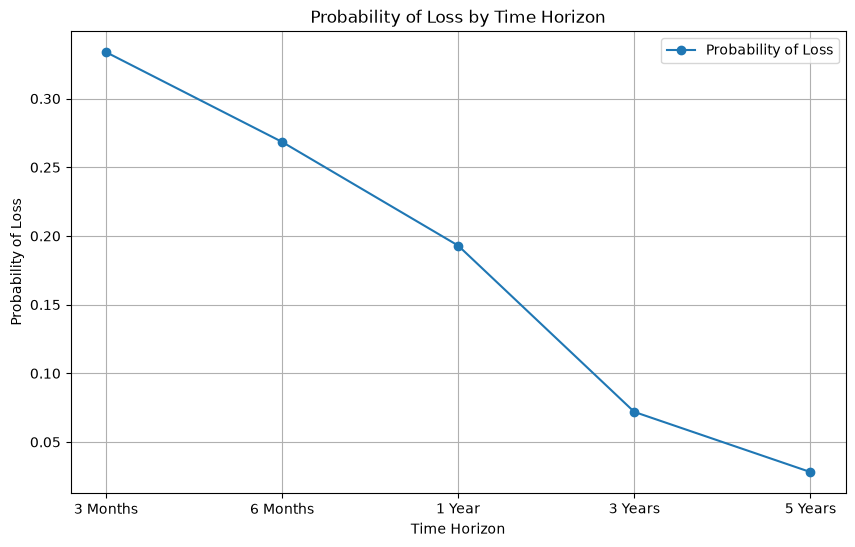

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    horizon_sensitivity_df["Time Horizon"],
    horizon_sensitivity_df["Probability of Loss"],
    marker="o",
    label="Probability of Loss"
)

plt.title("Probability of Loss by Time Horizon")
plt.xlabel("Time Horizon")
plt.ylabel("Probability of Loss")
plt.grid(True)
plt.legend()

plt.savefig(
    IMAGES_DIR / "sensitivity_time_horizon_probability_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

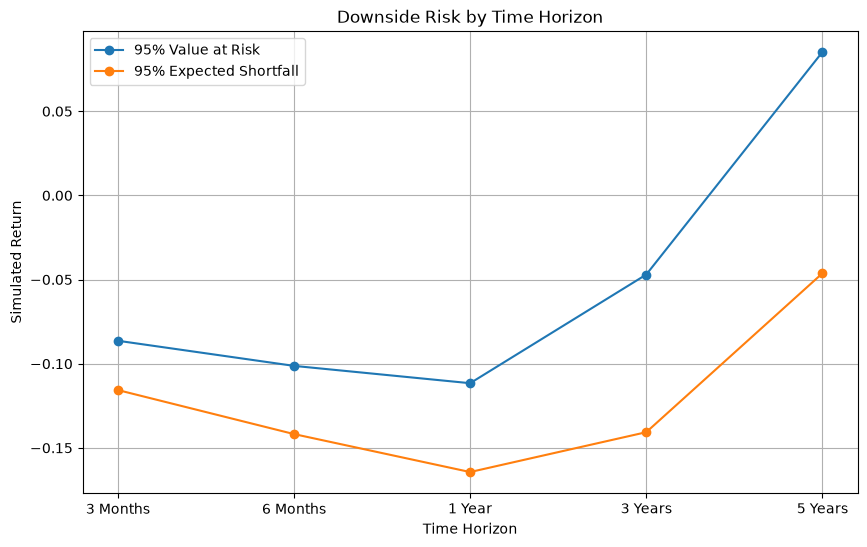

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    horizon_sensitivity_df["Time Horizon"],
    horizon_sensitivity_df["95% Value at Risk"],
    marker="o",
    label="95% Value at Risk"
)

plt.plot(
    horizon_sensitivity_df["Time Horizon"],
    horizon_sensitivity_df["95% Expected Shortfall"],
    marker="o",
    label="95% Expected Shortfall"
)

plt.title("Downside Risk by Time Horizon")
plt.xlabel("Time Horizon")
plt.ylabel("Simulated Return")
plt.grid(True)
plt.legend()

plt.savefig(
    IMAGES_DIR / "sensitivity_time_horizon_downside_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sensitivity to Initial Portfolio Value

Changing the initial portfolio value does not change percentage returns, but it changes the monetary size of potential gains and losses.

In [10]:
initial_values = [10_000, 50_000, 100_000, 250_000]

initial_value_sensitivity_results = []

for initial_value in initial_values:
    paths, final_values = run_parametric_monte_carlo(
        returns=returns,
        weights=weights,
        initial_value=initial_value,
        n_simulations=base_n_simulations,
        time_horizon=base_time_horizon,
        random_seed=42
    )

    simulated_returns = final_values / initial_value - 1

    var_95_return = np.percentile(simulated_returns, 5)
    expected_shortfall_95_return = simulated_returns[
        simulated_returns <= var_95_return
    ].mean()

    result = {
        "Initial Value": initial_value,
        "Mean Final Value": final_values.mean(),
        "95% VaR Return": var_95_return,
        "95% VaR Dollar Loss": initial_value * abs(var_95_return),
        "95% Expected Shortfall Return": expected_shortfall_95_return,
        "95% Expected Shortfall Dollar Loss": initial_value * abs(expected_shortfall_95_return)
    }

    initial_value_sensitivity_results.append(result)

initial_value_sensitivity_df = pd.DataFrame(initial_value_sensitivity_results)

initial_value_sensitivity_df.to_csv(
    OUTPUTS_DIR / "sensitivity_initial_portfolio_value.csv",
    index=False
)

initial_value_sensitivity_df

,Initial Value,Mean Final Value,95% VaR Return,95% VaR Dollar Loss,95% Expected Shortfall Return,95% Expected Shortfall Dollar Loss
0,10000,11500.850986,-0.111579,1115.793100,-0.164366,1643.662409
1,50000,57504.254931,-0.111579,5578.965501,-0.164366,8218.312044
2,100000,115008.509861,-0.111579,11157.931001,-0.164366,16436.624087
3,250000,287521.274653,-0.111579,27894.827503,-0.164366,41091.560218


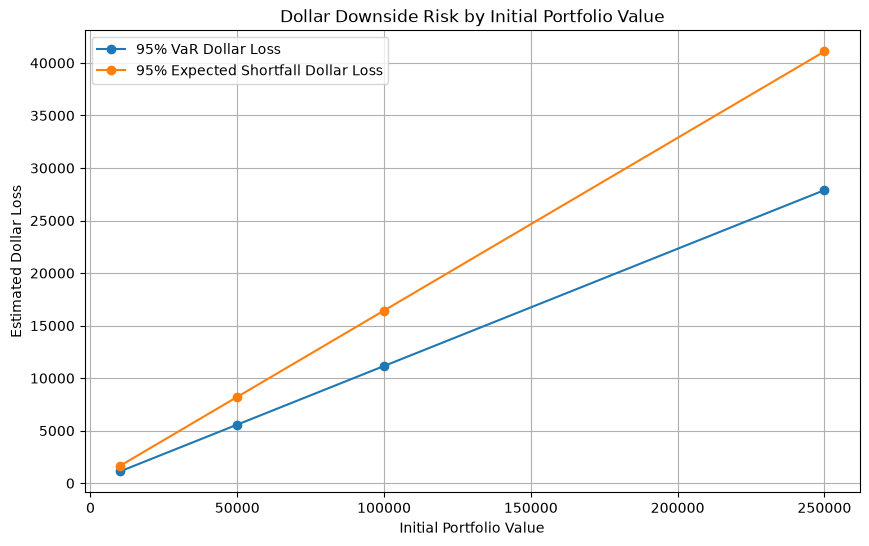

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    initial_value_sensitivity_df["Initial Value"],
    initial_value_sensitivity_df["95% VaR Dollar Loss"],
    marker="o",
    label="95% VaR Dollar Loss"
)

plt.plot(
    initial_value_sensitivity_df["Initial Value"],
    initial_value_sensitivity_df["95% Expected Shortfall Dollar Loss"],
    marker="o",
    label="95% Expected Shortfall Dollar Loss"
)

plt.title("Dollar Downside Risk by Initial Portfolio Value")
plt.xlabel("Initial Portfolio Value")
plt.ylabel("Estimated Dollar Loss")
plt.grid(True)
plt.legend()

plt.savefig(
    IMAGES_DIR / "sensitivity_initial_value_dollar_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sensitivity to Risk-Free Rate Assumption

The risk-free rate affects the Sharpe Ratio, which measures risk-adjusted return.

In [12]:
risk_free_rates = [0.00, 0.02, 0.04, 0.05]

portfolio_daily_returns = returns @ weights.values

annualized_return = portfolio_daily_returns.mean() * trading_days
annualized_volatility = portfolio_daily_returns.std() * np.sqrt(trading_days)

risk_free_sensitivity_results = []

for rf in risk_free_rates:
    sharpe_ratio = (annualized_return - rf) / annualized_volatility

    risk_free_sensitivity_results.append({
        "Risk-Free Rate": rf,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio
    })

risk_free_sensitivity_df = pd.DataFrame(risk_free_sensitivity_results)

risk_free_sensitivity_df.to_csv(
    OUTPUTS_DIR / "sensitivity_risk_free_rate.csv",
    index=False
)

risk_free_sensitivity_df

,Risk-Free Rate,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.00,0.138521,0.149518,0.926453
1,0.02,0.138521,0.149518,0.792689
2,0.04,0.138521,0.149518,0.658926
3,0.05,0.138521,0.149518,0.592044


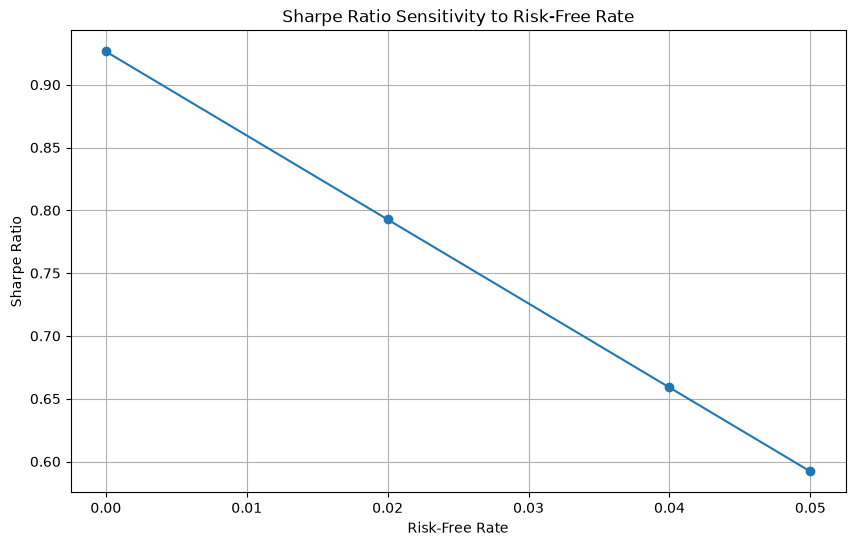

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    risk_free_sensitivity_df["Risk-Free Rate"],
    risk_free_sensitivity_df["Sharpe Ratio"],
    marker="o"
)

plt.title("Sharpe Ratio Sensitivity to Risk-Free Rate")
plt.xlabel("Risk-Free Rate")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "sensitivity_risk_free_rate_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sensitivity Analysis Interpretation

The sensitivity analysis shows how Monte Carlo results depend on key assumptions.

Increasing the number of simulations generally makes risk estimates more stable, especially Value at Risk and Expected Shortfall.

Changing the time horizon has a significant effect on final portfolio value distributions and downside risk. Longer horizons may increase the range of possible outcomes.

Changing the initial portfolio value does not change percentage returns, but it changes the monetary size of potential losses and gains.

The risk-free rate affects the Sharpe Ratio. A higher risk-free rate reduces the portfolio's excess return and therefore lowers its risk-adjusted performance.

Overall, this notebook improves the robustness of the project by showing that risk estimates should be interpreted in relation to the assumptions used in the model.